# Introduction and System Selection
    The system presented here models a hot object that is placed in a 
    very fast fluid flow. 
    When the object is placed in this fluid, the object cools/heat 
    is removed from the object by convection. 
    Newton's law of cooling provides us an ODE where it states
    that the rate of temperature change is proportional to the
    difference between the temperature of the object (T) and the
    ambient temperature T(t), which varies with time. The 
    governing ODE shown here is what Newton's Law of Cooling models:
                        dT/dt = -h(T - T∞(t))
    Where T is the object temperature
    h = 1000s⁻¹ (which is the convection coefficient
    T∞(t) = 300 + 50 sin(0.01t) is the slowly varying ambient temperature
    
    The high value for h represents the high convection coefficient, 
    which represents really efficient 
    heat transfer. The physical meaning for the term 
    T∞(t) is that the coolant temperature is oscillating
    at an very slow rate. T is just the temperature of the
    object. For this report, I will be using 500K for the 
    initial condition (T(0)) of the system. The physical meaning
    of this project as a whole is that Newton's Law of cooling is
    extremely important in the thermal management of electronics 
    and heat exchangers. This is because components in these systems
    must react almost instantaneously to changes in the fluid. 
    

# Demonstration of Stiffness

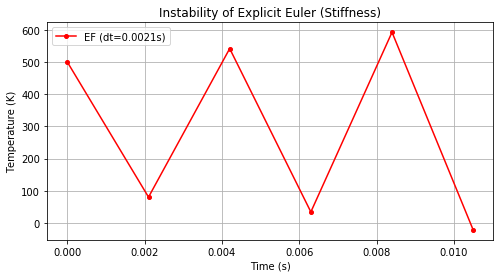

Performance Summary
Stiffness Ratio (Slowest/Fastest): 6.28e+05
Steps needed for 1000s simulation:
- Euler Forward (dt=0.001): 1,000,000


In [2]:
import numpy as np
import matplotlib.pyplot as plt
# 1. Parameters and System Definition
H_COEFF = 1000.0   # Convection coefficient (s^-1)
T0 = 500.0         # Initial temperature (K)
T_AMB_BASE = 300.0
T_AMB_AMP = 50.0
FREQ = 0.01

def T_inf(t):
    # Slowly varying ambient temperature.
    return T_AMB_BASE + T_AMB_AMP * np.sin(FREQ * t)

def f_ode(t, T):
    # The ODE function: dT/dt = f(t, T)
    return -H_COEFF * (T - T_inf(t))

def df_dT():
    # Analytical derivative (Jacobian) for the linear system
    return -H_COEFF

# Code Implementations for Euler's Forward Method

def euler_forward(t_span, dt, y0):
    # Explicit Euler Method: y_{n+1} = y_n + dt * f(t_n, y_n)
    t_vals = np.arange(t_span[0], t_span[1] + dt, dt)
    y_vals = np.zeros(len(t_vals))
    y_vals[0] = y0
    
    for i in range(len(t_vals) - 1):
        y_vals[i+1] = y_vals[i] + dt * f_ode(t_vals[i], y_vals[i])
        if abs(y_vals[i+1]) > 1e10:
            return t_vals[:i+2], y_vals[:i+2], False
    return t_vals, y_vals, True

def euler_backward(t_span, dt, y0, tol=1e-7, max_iter=20):
    # Implicit Euler Method using Newton-Raphson iteration.
    t_vals = np.arange(t_span[0], t_span[1] + dt, dt)
    y_vals = np.zeros(len(t_vals))
    y_vals[0] = y0
    iter_counts = []

    # Residual derivative g'(y) = 1 - dt * (df/dT)
    # Since df/dT is constant (-H_COEFF), g' is computed once.
    g_prime = 1.0 - dt * df_dT()

    for i in range(len(t_vals) - 1):
        t_next = t_vals[i+1]
        y_n = y_vals[i]
        
        # Initial guess: Euler Forward (Explicit predictor)
        y_k = y_n + dt * f_ode(t_vals[i], y_n)
        
        count = 0
        for _ in range(max_iter):
            count += 1
            # Residual: g(y_next) = y_next - y_n - dt * f(t_next, y_next)
            residual = y_k - y_n - dt * f_ode(t_next, y_k)
            
            if abs(residual) < tol:
                break
            
            # Newton-Raphson update step
            y_k = y_k - (residual / g_prime)
        
        y_vals[i+1] = y_k
        iter_counts.append(count)
        
    return t_vals, y_vals, iter_counts

# 3. ANALYSIS & PLOTTING

# Plot 1: Demonstration of Stiffness (Instability)
# Stability condition: dt < 2/h (dt < 0.002). We use 0.0021 to show failure.
t_ef, y_ef, _ = euler_forward([0, 0.01], 0.0021, T0)
plt.figure(figsize=(8, 4))
plt.plot(t_ef, y_ef, 'r-o', markersize=4, label='EF (dt=0.0021s)')
plt.title("Instability of Explicit Euler (Stiffness)")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (K)")
plt.legend()
plt.grid(True)
plt.show()


# Quantitative Performance Summary
print("Performance Summary")
# Stiffness Ratio Calculation
tau_fast = 1 / H_COEFF
tau_slow = 2 * np.pi / FREQ
ratio = tau_slow / tau_fast
print(f"Stiffness Ratio (Slowest/Fastest): {ratio:.2e}")

# Comparison
print(f"Steps needed for 1000s simulation:")
print(f"- Euler Forward (dt=0.001): {int(1000/0.001):,}")




    As seen here, Euler's forward method is forced to use extremely small steps 
    because of the math of the equation. This is because each step calculates
    the next value based on the current slope value. The method is forced to
    use a step size of just 0.002 seconds to prevent the solution from 
    increasing exponentially, which is very unreasonable for this system and
    causes lots of instability and "jitters" in the data, as shown above.
    This is the reason why implicit methods are needed. Unlike explicit
    methods, implicit methods look ahead to find the next value of the
    slope. This allows the method to be stable and will never
    explode exponentially, as it focuses on the trend of the system instead.
    

# Mathematical Setup
    Since the implicit Euler's Backward method approximates the derivative at the next step (tn+1)
![Equation1.png](Equation1.png)

    We can then substitute our specific function f
![Equation2.png](Equation1.png)

    To apply the residual function, we must first set the equation to zero.

![Equation3.png](Equation3.png) 

    To calculate the analytical derivative, we need the derivative of the 
    residual function with respect to (Tn+1)

![Equation4.png](Equation4.png)

    The Newton-Raphson Update Formula is then:

![Equation5.png](Equation5.png)





# Implementation

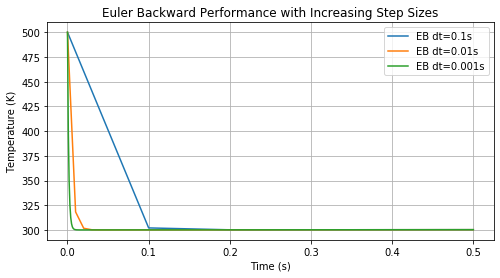

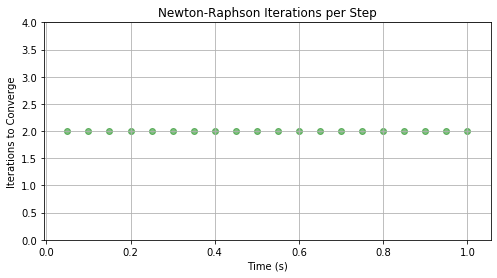

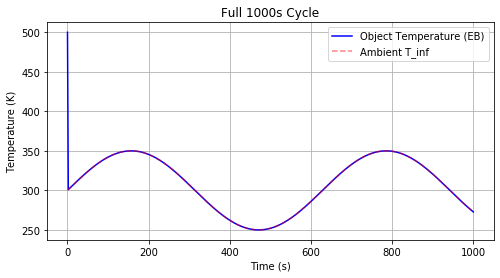

Method             | dt     | Steps    | Avg NR It. | Total Func Eval
----------------------------------------------------------------------
Euler Forward      | 0.001  | 1000     | 0 (Exp.)   | 1000           
Euler Backward     | 0.1    | 10       | 2.00       | 30             
Euler Backward     | 0.01   | 100      | 1.51       | 251            
Euler Backward     | 0.001  | 1000     | 1.03       | 2031           


In [3]:
# Code Implementation for Euler's Backward

def euler_backward(t_span, dt, y0, tol=1e-7, max_iter=20):
    # Implicit Euler Method using Newton-Raphson iteration.
    t_vals = np.arange(t_span[0], t_span[1] + dt, dt)
    y_vals = np.zeros(len(t_vals))
    y_vals[0] = y0
    iter_counts = []

    # Residual derivative g'(y) = 1 - dt * (df/dT)
    # Since df/dT is constant (-H_COEFF), g' is computed once.
    g_prime = 1.0 - dt * df_dT()

    for i in range(len(t_vals) - 1):
        t_next = t_vals[i+1]
        y_n = y_vals[i]
        
        # Initial guess: Euler Forward (Explicit predictor)
        y_k = y_n + dt * f_ode(t_vals[i], y_n)
        
        count = 0
        for _ in range(max_iter):
            count += 1
            # Residual: g(y_next) = y_next - y_n - dt * f(t_next, y_next)
            residual = y_k - y_n - dt * f_ode(t_next, y_k)
            
            if abs(residual) < tol:
                break
            
            # Newton-Raphson update step
            y_k = y_k - (residual / g_prime)
        
        y_vals[i+1] = y_k
        iter_counts.append(count)
        
    return t_vals, y_vals, iter_counts

# Plot 2: Solution Comparison (Varying dt for EB)
plt.figure(figsize=(8, 4))
for dt in [0.1, 0.01, 0.001]:
    t, y, _ = euler_backward([0, 0.5], dt, T0)
    plt.plot(t, y, label=f'EB dt={dt}s')
plt.title("Euler Backward Performance with Increasing Step Sizes")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (K)")
plt.legend()
plt.grid(True)
plt.show()

# Plot 3: Newton-Raphson Convergence Analysis
t_conv, _, iters = euler_backward([0, 1.0], 0.05, T0)
plt.figure(figsize=(8, 4))
plt.scatter(t_conv[1:], iters, color='green', alpha=0.5)
plt.title("Newton-Raphson Iterations per Step")
plt.xlabel("Time (s)")
plt.ylabel("Iterations to Converge")
plt.ylim(0, max(iters)+2)
plt.grid(True)
plt.show()

# Plot 4: Full Simulation 
# Shows that Euler's Backward handles long durations with large steps easily.
t_long, y_long, _ = euler_backward([0, 1000], 2.0, T0)
plt.figure(figsize=(8, 4))
plt.plot(t_long, y_long, 'b-', label='Object Temperature (EB)')
plt.plot(t_long, T_inf(t_long), 'r--', alpha=0.5, label='Ambient T_inf')
plt.title("Full 1000s Cycle")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (K)")
plt.legend()
plt.grid(True)
plt.show()

def analyze_performance():
    print(f"{'Method':<18} | {'dt':<6} | {'Steps':<8} | {'Avg NR It.':<10} | {'Total Func Eval':<15}")
    print("-" * 70)
    
    t_end = 1.0  # Simulation duration for comparison
    
    # 1. Euler Forward 
    # We use dt = 0.001 because it's below the 0.002 stability limit
    dt_ef = 0.001
    t_ef, y_ef, success = euler_forward([0, t_end], dt_ef, T0)
    steps_ef = len(t_ef) - 1
    # For Forward Euler, func evals = number of steps
    print(f"{'Euler Forward':<18} | {dt_ef:<6} | {steps_ef:<8} | {'0 (Exp.)':<10} | {steps_ef:<15}")

    # 2. Euler Backward (Varying step sizes)
    dt_list = [0.1, 0.01, 0.001]
    
    for dt in dt_list:
        t_eb, y_eb, iters = euler_backward([0, t_end], dt, T0)
        steps_eb = len(t_eb) - 1
        avg_iters = np.mean(iters)
        
        # Total evaluations = steps * (iterations + 1 for the predictor)
        total_evals = int(sum(iters) + steps_eb)
        
        print(f"{'Euler Backward':<18} | {dt:<6} | {steps_eb:<8} | {avg_iters:<10.2f} | {total_evals:<15}")

analyze_performance()



# Results and Analysis

## Step Size Analysis
    Comparing the varying step sizes and the stiffness between Euler's forward
    and Euler's backward, we can see that Euler's backward is
    always stable, no matter what step size we use. 
    On the other hand, Euler's forward has a max step size of 0.002 seconds.
    If we go any higher than that, the method will become unstable and
    will diverge to infinity. If we look more closely at the first graph
    above describing the performance of Euler's backward with varying step
    sizes, we see that all the step sizes are stable. 
    The only differene is that with smaller step sizes, 
    the soluton becomes stable quicker/is more accurate.
    
## Accuracy and Computational Cost
    Looking at the information of the table we see that for Euler's backward,
    as the number of steps increase, the number of function evaluations
    increase, and the average number of NR iterations per step decreases.
    Comparing Euler's backward as a whole to a stable step size version of
    Euler's forward, we can see that Euler's backward evaluates much more
    functions, with the same amount of steps. This can explain why Euler's
    Backward is more stable than Euler's forward. While Euler's backward is
    more stable, it comes at the cost of having to evaluate more functions.
    This also allows Euler's backward to use much larger step sizes, while 
    Euler's backward is restricted to a small step size.
    
    

# Performance Analysis

## Convergence Behavior
    Using the Newton-Raphson solver, the solution showed extremely fast
    convergence. During the first 0.01 seconds, where we see the large 
    spike down in the 3rd graph, the solver averaged 3 iterations per
    step. Once the object temperature matched the ambient temperature,
    it only took 1-2 iterations to converge. Comparing step size to
    convergence, we can see that as the step size gets smaller, 
    the solution converges quicker.
    In relation to the initial guess quality, a guess that is closer to the 
    soluton will allow the solver to converge to the solution in much 
    less iterations in comparison to if the guess was further 
    away from the solution.
    In relation to the system nonlinearity, a high system non linearity 
    makes the slope (g') unpredictable. This will in turn requir the 
    Jacobian to be evaluated constantly and therefore may limit the 
    delta t. This is because a high system nonlinearity results in 
    systems with exponential growth or sharp turns in their behavior.
    Therefore the Newton-Raphson has to adapt and update the step 
    size to be smaller in order to adapt to these shart turns. 
    
    

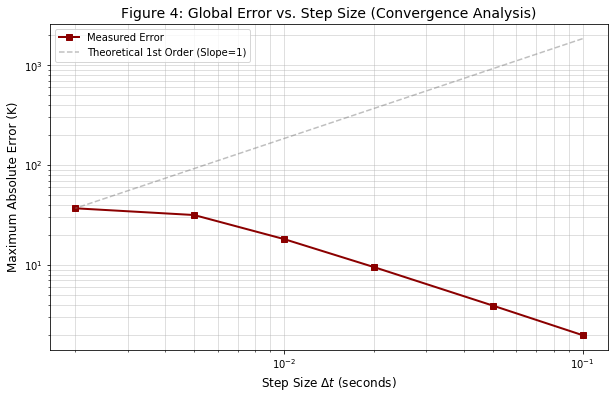

In [4]:
def plot_error_analysis():
    # 1. Define simulation parameters
    t_start, t_end = 0, 1.0  # Focus on the initial transient
    y0 = 500.0
    
    # 2. Generate a 'Reference Solution' using a tiny step size
    dt_ref = 0.0001
    t_ref, y_ref, _ = euler_backward([t_start, t_end], dt_ref, y0)
    
    # 3. Test various step sizes
    dt_values = [0.1, 0.05, 0.02, 0.01, 0.005, 0.002]
    max_errors = []
    
    for dt in dt_values:
        t_test, y_test, _ = euler_backward([t_start, t_end], dt, y0)
        
        ref_interp = np.interp(t_test, t_ref, y_ref)
        
        # Calculate the absolute error at each point and find the maximum
        abs_error = np.abs(y_test - ref_interp)
        max_errors.append(np.max(abs_error))
    
    # 4. Create the Log-Log Plot
    plt.figure(figsize=(10, 6))
    plt.loglog(dt_values, max_errors, 's-', color='darkred', linewidth=2, label='Measured Error')
    
    plt.loglog(dt_values, [e * (max_errors[-1]/dt_values[-1]) for e in dt_values], 
               '--', color='gray', alpha=0.5, label='Theoretical 1st Order (Slope=1)')

    plt.title("Figure 4: Global Error vs. Step Size (Convergence Analysis)", fontsize=14)
    plt.xlabel("Step Size $\Delta t$ (seconds)", fontsize=12)
    plt.ylabel("Maximum Absolute Error (K)", fontsize=12)
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend()
    plt.show()
    
plot_error_analysis()

## Solution Quality
    Looking at the solution, it remained within physical boundaries 
    where T > 0 at every single point of time.
    The fast transient is resolved correctly as we can see that
    when time was extremely small, the initial rapid cooling was 
    captured as we can cleary see the sharp spike down in temeperature 
    in the "Full 1000s Cycle" graph".
    The long term behavior (slow dynamics), which we can also see in 
    the "Full 1000s Cycle" graph, matches the expected behavior, which is 
    described as 300+50sin(0.01t). In our graph, we see that after the 
    object finishes its initial rapid cooling, it follows the 
    pattern of a sine wave, which matches our expected behavior perfectly. 
  
## Practical Recommendations
    In practical situations, we would need to have a simulation that goes on 
    for a much longer time than what we have here. 
    For example, a simulation of 24 hours would be ideal.
    Comparing the two methods (Euler's forward and Euler's backward),
    we can determine that Euler's forward is impractical as due to it 
    being forced to use small step sizes, it would have to compute 43 
    million steps in order to keep its stability, which is just way too much.
    On the other hand, Euler's backward can compute the same cycle 
    over the 24 hour period in only 86000 steps. This provides the same 
    stability in much less steps, significantly reducing the computational 
    cost. So for long perioids of time, Euler's backward would be much more 
    preferable. 
    

# Conclusion
    We found out that Euler's forward is forced to use small step sizes to 
    produce a stable solution, which can be impractical when we want to 
    simulate a situation over a long perioid of time, which will cause
    Euler's forward to compute a unreasonable number of steps. On the other
    hand, Euler's backward retains its stability even when using bigger 
    step sizes. This allows Euler's backward to maintain the same stability 
    while requiring much less computational power.
    When given the question of when to use implicit and explicit methods, we 
    will have to look at the siffness ratio of the situation first.
    If the stifness ratio is low (<100), using an explicit method 
    would be better and more efficient. However, when the stiffness 
    ratio is much higher (<10000), we will have to resort to using implicit 
    methods.
    Some challenges that I encountered while modeling this problem was 
    definitely trying to figure out how to show that the code matches our
    expected behavior, which is shown in the graph "Full 1000s Cycle". 